# Proyecto #3 — CC3085 Inteligencia Artificial
## Clasificador SPAM/HAM con Naive Bayes


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter, defaultdict
from wordcloud import WordCloud
import string
import random
import math
import warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("omw-1.4",   quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

COLOR_SPAM = "#E74C3C"
COLOR_HAM  = "#2ECC71"
print("✓ Librerías cargadas.")

✓ Librerías cargadas.


---
## A. Análisis Exploratorio de Datos (EDA)


In [3]:
import pandas as pd

df = pd.read_csv(
    "spam_ham.csv",
    encoding="latin-1",
    sep=";",
    header=None,
    names=["label", "message"],
    engine="python"
)

df["label"] = df["label"].astype(str).str.strip().str.lower()
df["message"] = df["message"].astype(str).str.strip()
df["length"] = df["message"].str.len()

print(f"Dimensiones    : {df.shape}")
print(f"Etiquetas      : {df['label'].unique()}")
print(f"Total mensajes : {len(df)}")
print(df["label"].value_counts().to_string())

display(df.head(8))

Dimensiones    : (5566, 3)
Etiquetas      : ['label' 'ham' 'spam' 'ham"""']
Total mensajes : 5566
label
ham       4817
spam       746
ham"""       2
label        1


,label,message,length
0,label,SMS_TEXT,8
1,ham,"Go until jurong point, crazy.. Available only ...",111
2,ham,Ok lar... Joking wif u oni...,29
3,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
4,ham,U dun say so early hor... U c already then say...,49
5,ham,"Nah I don't think he goes to usf, he lives aro...",61
6,spam,FreeMsg Hey there darling it's been 3 week's n...,149
7,ham,Even my brother is not like to speak with me. ...,77


In [4]:
import numpy as np
print(np.__version__)

1.26.4


In [5]:
# ── 5 mensajes aleatorios ────────────────────────────────────────────────────
print("── 5 mensajes aleatorios ──")
for i, idx in enumerate(random.sample(range(len(df)), 5), 1):
    row = df.iloc[idx]
    print(f"\n[{i}] {row['label'].upper()}: {row['message'][:120]}{'...' if len(row['message'])>120 else ''}")

── 5 mensajes aleatorios ──

[1] HAM: Nothing will ever be easy. But don't be looking for a reason not to take a risk on life and love

[2] HAM: K..k...from tomorrow onwards started ah?

[3] HAM: No shoot me. I'm in the docs waiting room. :/

[4] SPAM: Freemsg: 1-month unlimited free calls! Activate SmartCall Txt: CALL to No: 68866. Subscriptn3gbp/wk unlimited calls Help...

[5] HAM: And maybe some pressies


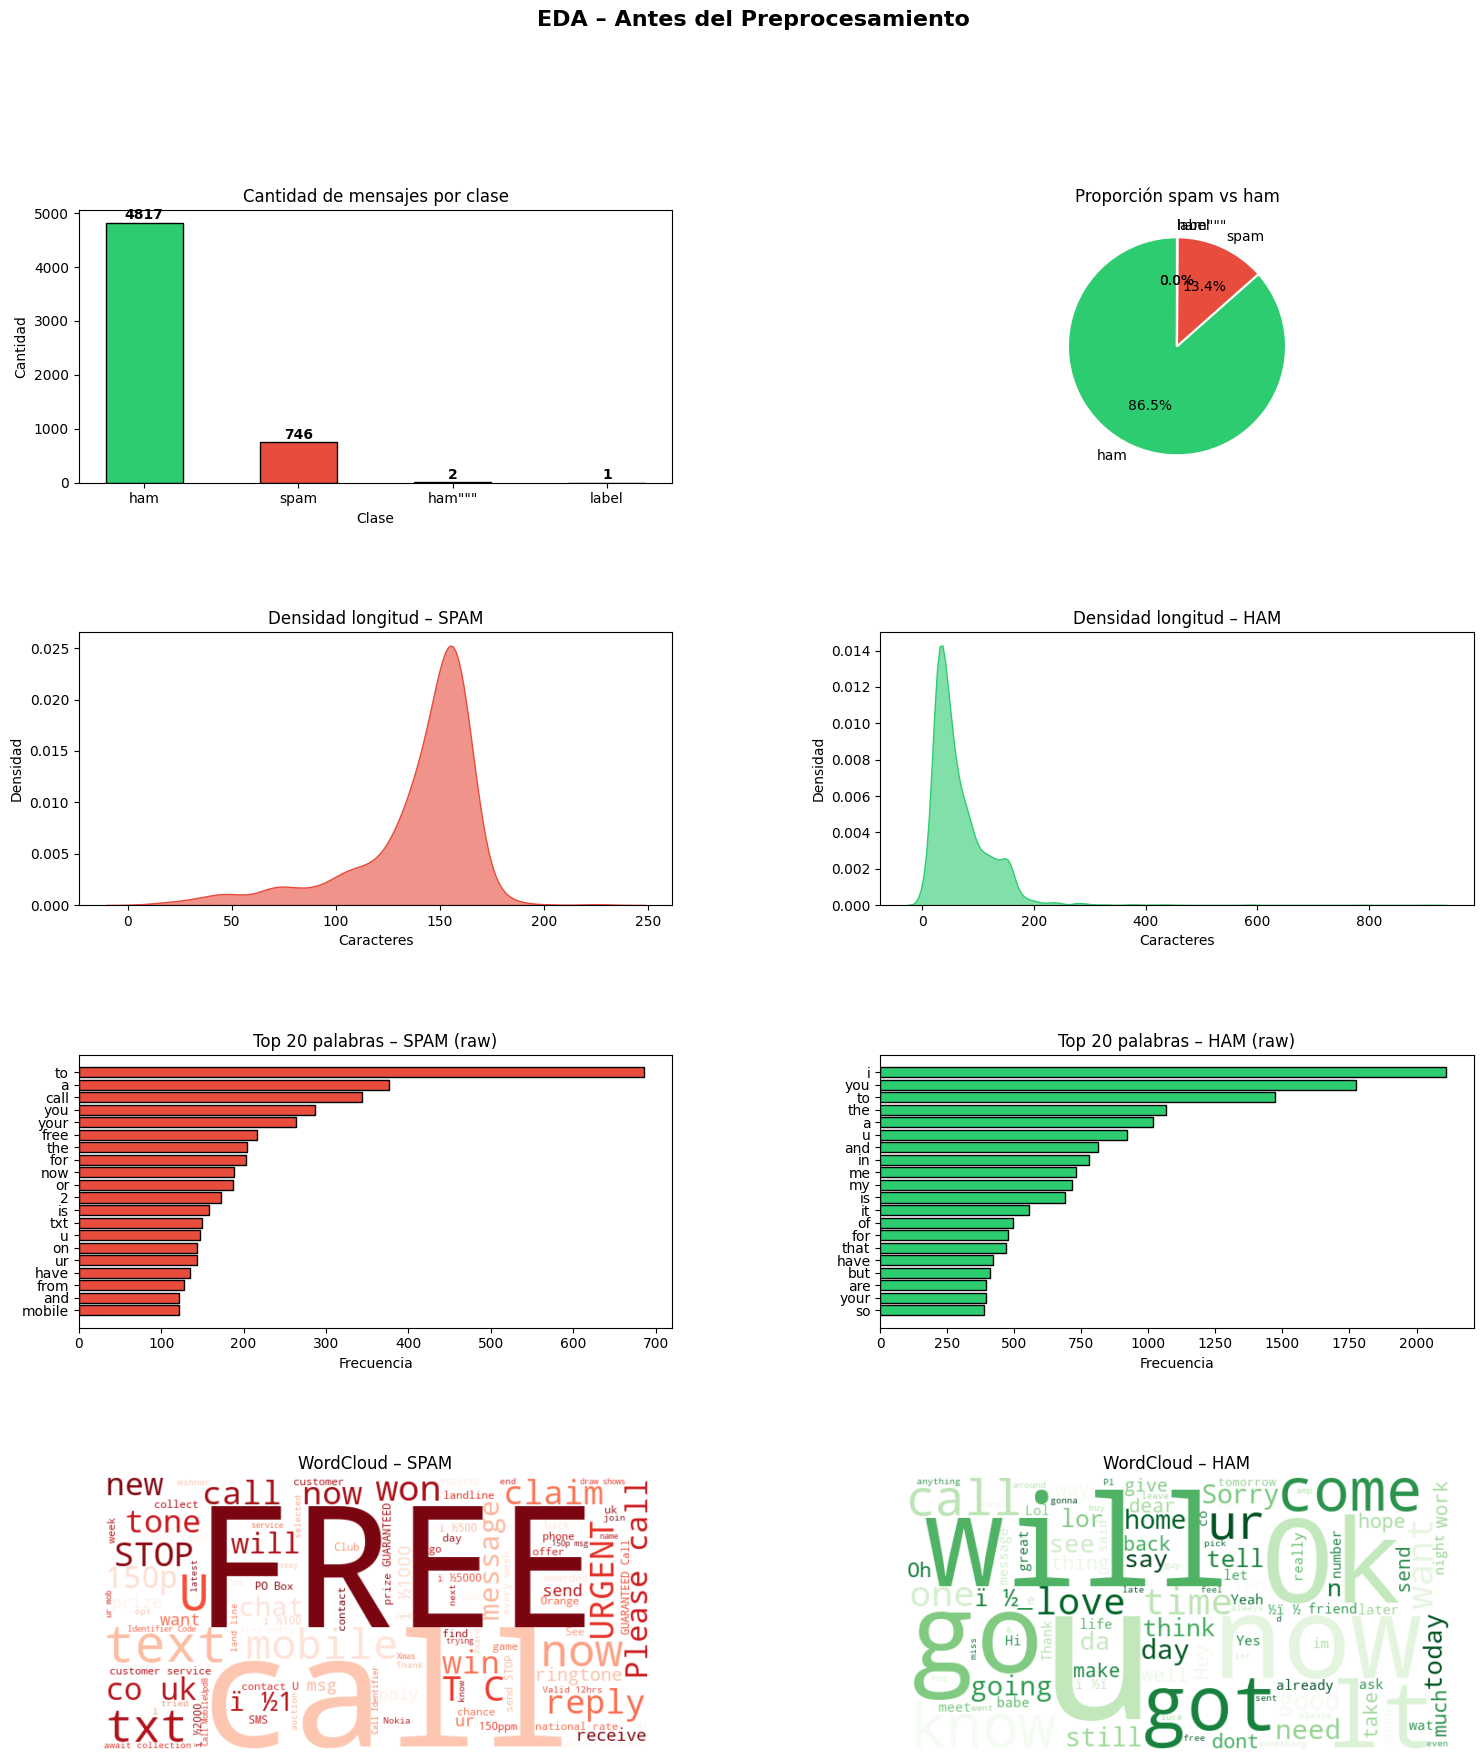

[✓] eda_antes.png guardada.


In [6]:
# ── Visualizaciones EDA (antes del preprocesamiento) ─────────────────────────
spam_df = df[df["label"] == "spam"]
ham_df  = df[df["label"] == "ham"]

def top_words(series, n=20):
    all_words = " ".join(series).lower().split()
    all_words = [w.strip(string.punctuation) for w in all_words if w.strip(string.punctuation)]
    return Counter(all_words).most_common(n)

fig = plt.figure(figsize=(18, 20))
fig.suptitle("EDA – Antes del Preprocesamiento", fontsize=16, fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

counts = df["label"].value_counts()

# (a) Conteo
ax1 = fig.add_subplot(gs[0,0])
bars = ax1.bar(counts.index, counts.values,
               color=[COLOR_HAM if l=="ham" else COLOR_SPAM for l in counts.index],
               edgecolor="black", width=0.5)
ax1.set_title("Cantidad de mensajes por clase"); ax1.set_xlabel("Clase"); ax1.set_ylabel("Cantidad")
for bar,v in zip(bars, counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, v+10, str(v), ha="center", va="bottom", fontweight="bold")

# (b) Proporción
ax2 = fig.add_subplot(gs[0,1])
ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=[COLOR_HAM if l=="ham" else COLOR_SPAM for l in counts.index],
        startangle=90, wedgeprops={"edgecolor":"white","linewidth":1.5})
ax2.set_title("Proporción spam vs ham")

# (c) Densidad spam
ax3 = fig.add_subplot(gs[1,0])
sns.kdeplot(spam_df["length"], ax=ax3, fill=True, color=COLOR_SPAM, alpha=0.6)
ax3.set_title("Densidad longitud – SPAM"); ax3.set_xlabel("Caracteres"); ax3.set_ylabel("Densidad")

# (d) Densidad ham
ax4 = fig.add_subplot(gs[1,1])
sns.kdeplot(ham_df["length"], ax=ax4, fill=True, color=COLOR_HAM, alpha=0.6)
ax4.set_title("Densidad longitud – HAM"); ax4.set_xlabel("Caracteres"); ax4.set_ylabel("Densidad")

# (e) Top20 spam
ax5 = fig.add_subplot(gs[2,0])
ws = top_words(spam_df["message"])
ax5.barh([w for w,_ in ws[::-1]], [c for _,c in ws[::-1]], color=COLOR_SPAM, edgecolor="black")
ax5.set_title("Top 20 palabras – SPAM (raw)"); ax5.set_xlabel("Frecuencia")

# (f) Top20 ham
ax6 = fig.add_subplot(gs[2,1])
wh = top_words(ham_df["message"])
ax6.barh([w for w,_ in wh[::-1]], [c for _,c in wh[::-1]], color=COLOR_HAM, edgecolor="black")
ax6.set_title("Top 20 palabras – HAM (raw)"); ax6.set_xlabel("Frecuencia")

# (g) WordCloud spam
ax7 = fig.add_subplot(gs[3,0])
wc = WordCloud(width=600, height=300, background_color="white", colormap="Reds", max_words=100)
wc.generate(" ".join(spam_df["message"].dropna().astype(str)))
ax7.imshow(wc, interpolation="bilinear"); ax7.axis("off"); ax7.set_title("WordCloud – SPAM")

# (h) WordCloud ham
ax8 = fig.add_subplot(gs[3,1])
wc2 = WordCloud(width=600, height=300, background_color="white", colormap="Greens", max_words=100)
wc2.generate(" ".join(ham_df["message"].dropna().astype(str)))
ax8.imshow(wc2, interpolation="bilinear"); ax8.axis("off"); ax8.set_title("WordCloud – HAM")

plt.savefig("eda_antes.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✓] eda_antes.png guardada.")

---
## B. Limpieza de Datos

Pipeline aplicado con NLTK:

| Paso | Técnica | Beneficio |
|------|---------|-----------|
| 1 | **Tokenización** | Divide el texto en unidades procesables |
| 2 | **Minúsculas** | Normaliza vocabulario (`Free` = `free`) |
| 3 | **Eliminar puntuación** | Elimina ruido sin significado semántico |
| 4 | **Eliminar stopwords** | Descarta palabras frecuentes poco informativas (`the`, `is`…) |
| 5 | **Lematización** | Reduce a forma canónica (`running→run`). Se elige sobre stemming porque produce palabras reales |


In [7]:
STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> list:
    """Retorna lista de tokens limpios."""
    tokens = word_tokenize(text)
    tokens = [t.lower() for t in tokens]
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [t for t in tokens if t not in STOP_WORDS]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

print("Aplicando preprocesamiento…")
df["tokens"]      = df["message"].apply(preprocess)
df["processed"]   = df["tokens"].apply(lambda t: " ".join(t))
df["proc_length"] = df["processed"].apply(len)
print(f"[✓] Listo. Ejemplo:")
print(f"  Original : {df['message'].iloc[2][:100]}")
print(f"  Procesado: {df['processed'].iloc[2][:100]}")

Aplicando preprocesamiento…
[✓] Listo. Ejemplo:
  Original : Ok lar... Joking wif u oni...
  Procesado: ok lar joking wif u oni


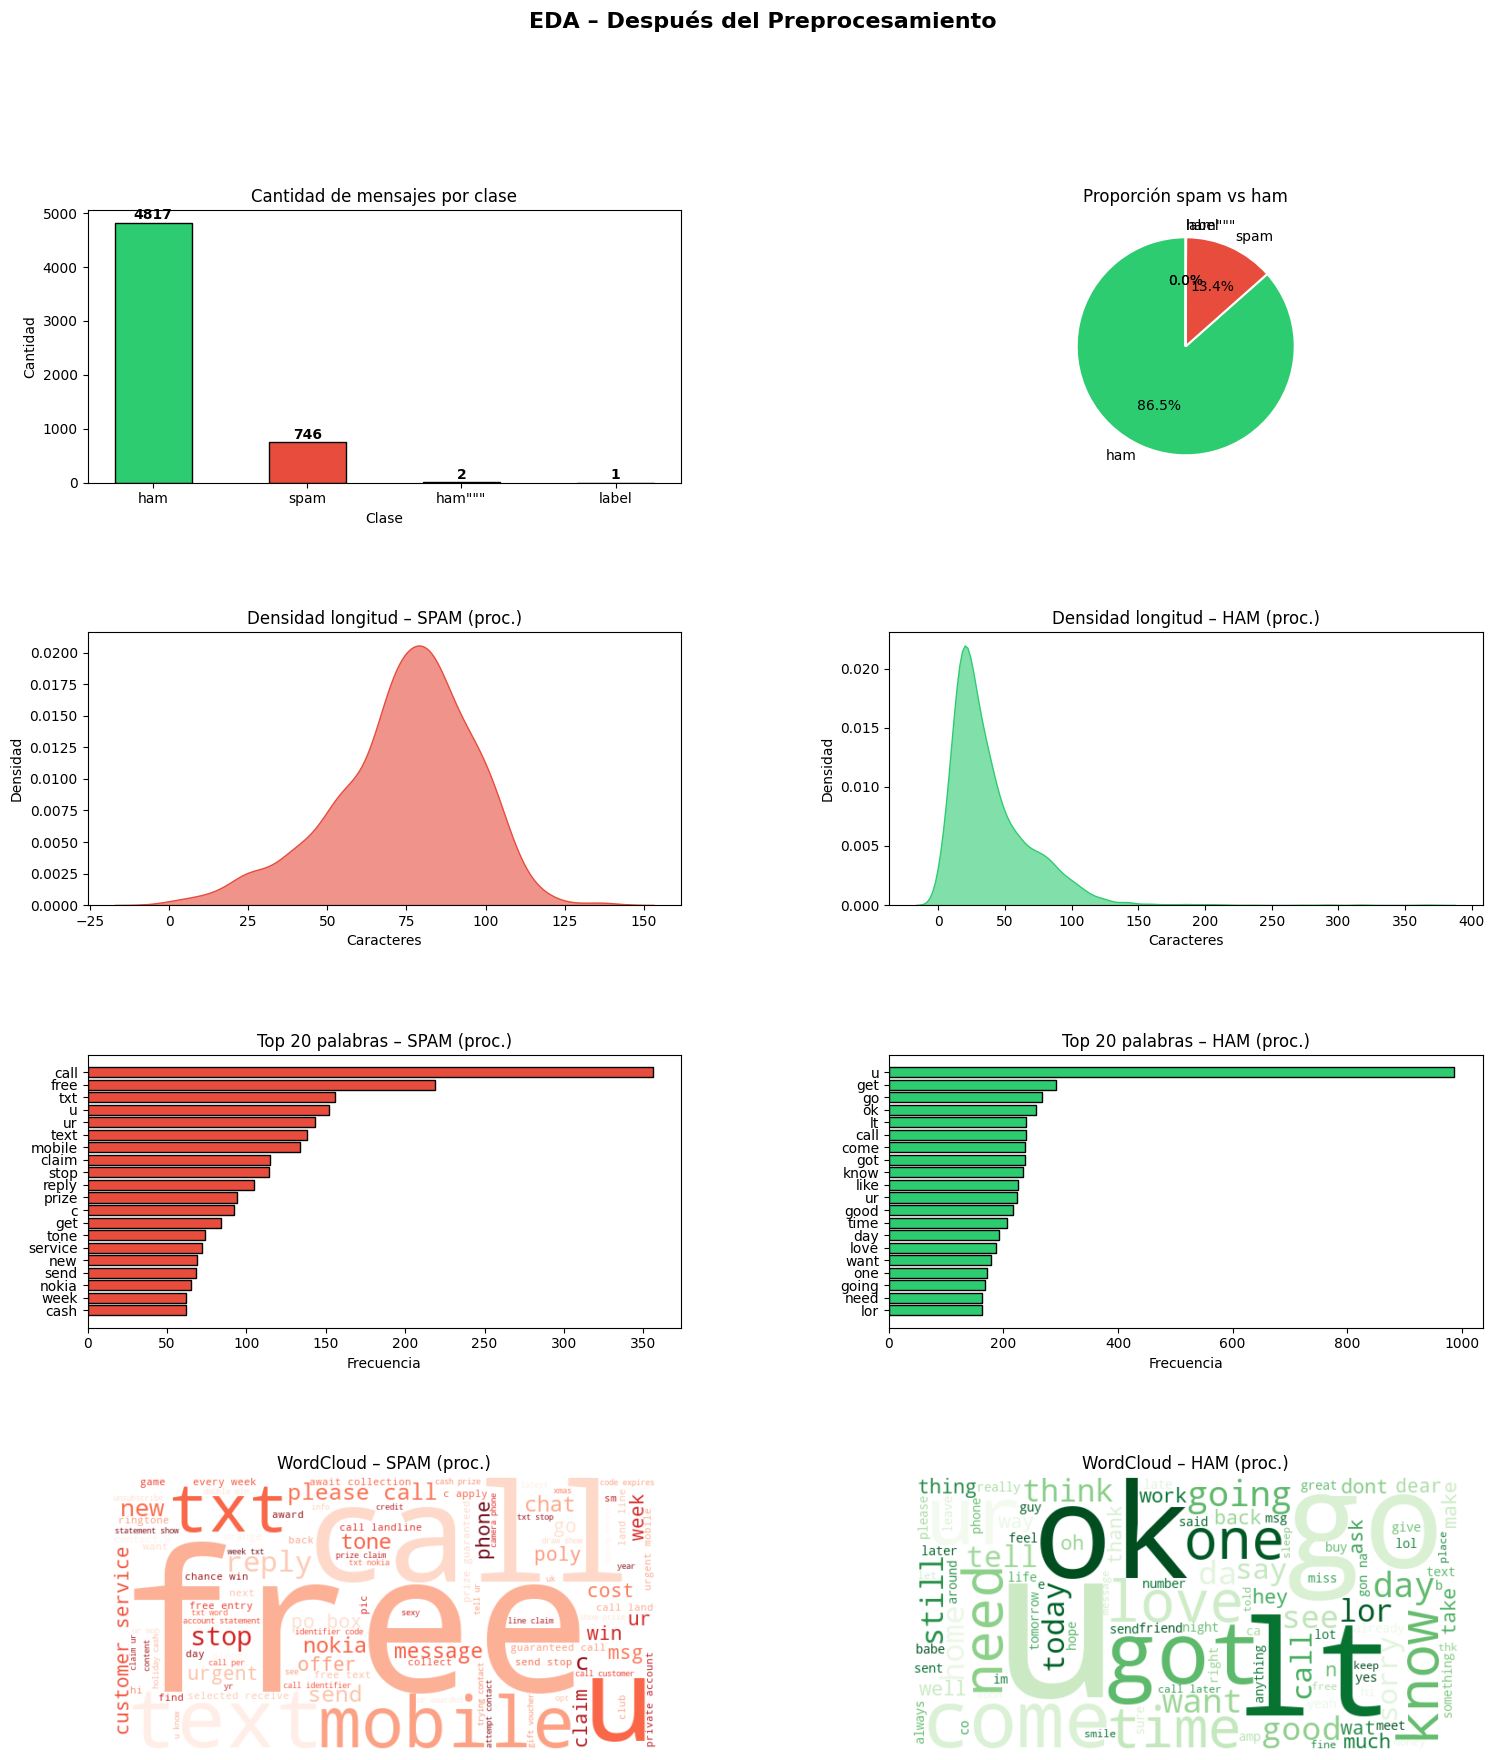

[✓] eda_despues.png guardada.


In [8]:
# ── Visualizaciones post-preprocesamiento ────────────────────────────────────
spam_proc = df[df["label"] == "spam"]
ham_proc  = df[df["label"] == "ham"]

fig2 = plt.figure(figsize=(18, 20))
fig2.suptitle("EDA – Después del Preprocesamiento", fontsize=16, fontweight="bold", y=0.98)
gs2  = gridspec.GridSpec(4, 2, figure=fig2, hspace=0.55, wspace=0.35)

counts = df["label"].value_counts()

ax1 = fig2.add_subplot(gs2[0,0])
bars = ax1.bar(counts.index, counts.values,
               color=[COLOR_HAM if l=="ham" else COLOR_SPAM for l in counts.index],
               edgecolor="black", width=0.5)
ax1.set_title("Cantidad de mensajes por clase"); ax1.set_xlabel("Clase"); ax1.set_ylabel("Cantidad")
for bar,v in zip(bars, counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2, v+10, str(v), ha="center", va="bottom", fontweight="bold")

ax2 = fig2.add_subplot(gs2[0,1])
ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=[COLOR_HAM if l=="ham" else COLOR_SPAM for l in counts.index],
        startangle=90, wedgeprops={"edgecolor":"white","linewidth":1.5})
ax2.set_title("Proporción spam vs ham")

ax3 = fig2.add_subplot(gs2[1,0])
sns.kdeplot(spam_proc["proc_length"], ax=ax3, fill=True, color=COLOR_SPAM, alpha=0.6)
ax3.set_title("Densidad longitud – SPAM (proc.)"); ax3.set_xlabel("Caracteres"); ax3.set_ylabel("Densidad")

ax4 = fig2.add_subplot(gs2[1,1])
sns.kdeplot(ham_proc["proc_length"], ax=ax4, fill=True, color=COLOR_HAM, alpha=0.6)
ax4.set_title("Densidad longitud – HAM (proc.)"); ax4.set_xlabel("Caracteres"); ax4.set_ylabel("Densidad")

ax5 = fig2.add_subplot(gs2[2,0])
wsp = top_words(spam_proc["processed"])
ax5.barh([w for w,_ in wsp[::-1]], [c for _,c in wsp[::-1]], color=COLOR_SPAM, edgecolor="black")
ax5.set_title("Top 20 palabras – SPAM (proc.)"); ax5.set_xlabel("Frecuencia")

ax6 = fig2.add_subplot(gs2[2,1])
whp = top_words(ham_proc["processed"])
ax6.barh([w for w,_ in whp[::-1]], [c for _,c in whp[::-1]], color=COLOR_HAM, edgecolor="black")
ax6.set_title("Top 20 palabras – HAM (proc.)"); ax6.set_xlabel("Frecuencia")

ax7 = fig2.add_subplot(gs2[3,0])
wc3 = WordCloud(width=600, height=300, background_color="white", colormap="Reds", max_words=100)
wc3.generate(" ".join(spam_proc["processed"].dropna()))
ax7.imshow(wc3, interpolation="bilinear"); ax7.axis("off"); ax7.set_title("WordCloud – SPAM (proc.)")

ax8 = fig2.add_subplot(gs2[3,1])
wc4 = WordCloud(width=600, height=300, background_color="white", colormap="Greens", max_words=100)
wc4.generate(" ".join(ham_proc["processed"].dropna()))
ax8.imshow(wc4, interpolation="bilinear"); ax8.axis("off"); ax8.set_title("WordCloud – HAM (proc.)")

plt.savefig("eda_despues.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✓] eda_despues.png guardada.")

---
## C. Modelo — Naive Bayes desde cero

Usando las fórmulas del anexo:

$$P(S|W) = \frac{P(W|S)\cdot P(S)}{P(W|S)\cdot P(S) + P(W|H)\cdot P(H)}$$

Para múltiples palabras W₁…Wₙ:

$$P(S|W) = \frac{p_1 p_2 \ldots p_n}{p_1 p_2 \ldots p_n + (1-p_1)(1-p_2)\ldots(1-p_n)}$$

donde cada $p_i = P(S|W_i)$


In [9]:
# ── Limpiar etiquetas inválidas antes del split ───────────────────────────────
print("Etiquetas antes de filtrar:")
print(df["label"].value_counts().to_string())

# Conservar solo filas con etiquetas válidas
df = df[df["label"].isin(["spam", "ham"])].reset_index(drop=True)

print(f"\nEtiquetas después de filtrar:")
print(df["label"].value_counts().to_string())
print(f"Total mensajes válidos: {len(df)}")

# ── Split 80/20 ───────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} mensajes  |  Test: {len(test_df)} mensajes")
print(f"Train spam/ham: {train_df['label'].value_counts().to_dict()}")
print(f"Test  spam/ham: {test_df['label'].value_counts().to_dict()}")

Etiquetas antes de filtrar:
label
ham       4817
spam       746
ham"""       2
label        1

Etiquetas después de filtrar:
label
ham     4817
spam     746
Total mensajes válidos: 5563

Train: 4450 mensajes  |  Test: 1113 mensajes
Train spam/ham: {'ham': 3853, 'spam': 597}
Test  spam/ham: {'ham': 964, 'spam': 149}


In [10]:
# ── Entrenamiento del modelo ──────────────────────────────────────────────────

# Priors: P(S) y P(H)
n_total = len(train_df)
n_spam  = (train_df["label"] == "spam").sum()
n_ham   = (train_df["label"] == "ham").sum()

P_S = n_spam / n_total
P_H = n_ham  / n_total

print(f"P(S) = {P_S:.4f}  |  P(H) = {P_H:.4f}")

# Conteos de palabras por clase (con Laplace smoothing alpha=1)
spam_train = train_df[train_df["label"] == "spam"]
ham_train  = train_df[train_df["label"] == "ham"]

spam_word_counts = Counter()
ham_word_counts  = Counter()

for tokens in spam_train["tokens"]:
    spam_word_counts.update(tokens)
for tokens in ham_train["tokens"]:
    ham_word_counts.update(tokens)

vocab = set(spam_word_counts.keys()) | set(ham_word_counts.keys())
V     = len(vocab)

total_spam_words = sum(spam_word_counts.values())
total_ham_words  = sum(ham_word_counts.values())

print(f"Vocabulario: {V} palabras únicas")
print(f"Palabras en spam: {total_spam_words}  |  Palabras en ham: {total_ham_words}")

# P(W|S) y P(W|H) con Laplace smoothing
def P_word_given_spam(word):
    return (spam_word_counts.get(word, 0) + 1) / (total_spam_words + V)

def P_word_given_ham(word):
    return (ham_word_counts.get(word, 0) + 1) / (total_ham_words + V)

# P(S|W) para una sola palabra — fórmula del anexo
def P_spam_given_word(word):
    pws = P_word_given_spam(word)
    pwh = P_word_given_ham(word)
    num = pws * P_S
    den = pws * P_S + pwh * P_H
    return num / den if den > 0 else 0.5

# Precomputar P(S|W) para todo el vocabulario
p_spam_given_word = {w: P_spam_given_word(w) for w in vocab}

print("\n[✓] Modelo entrenado.")
print("\nEjemplo de probabilidades por palabra:")
for w in ["free", "call", "win", "ok", "home", "love"]:
    print(f"  P(S|'{w}') = {p_spam_given_word.get(w, 0.5):.4f}")

P(S) = 0.1342  |  P(H) = 0.8658
Vocabulario: 5665 palabras únicas
Palabras en spam: 7537  |  Palabras en ham: 27547

[✓] Modelo entrenado.

Ejemplo de probabilidades por palabra:
  P(S|'free') = 0.5907
  P(S|'call') = 0.3641
  P(S|'win') = 0.6049
  P(S|'ok') = 0.0091
  P(S|'home') = 0.0061
  P(S|'love') = 0.0253


In [11]:
# ── Clasificación de un texto — fórmula combinada del anexo ──────────────────

def classify(text: str, threshold: float = 0.5):
    """
    Clasifica un texto como spam o ham.
    Retorna (probabilidad_spam, etiqueta, top3_palabras_predictivas)
    """
    tokens = preprocess(text)
    # Filtrar solo palabras en vocabulario
    tokens = [t for t in tokens if t in p_spam_given_word]

    if not tokens:
        return 0.5, "ham", []

    # Obtener p_i = P(S|Wi) para cada token
    p_vals = [(t, p_spam_given_word[t]) for t in tokens]

    # Fórmula combinada del anexo
    # P(S|W1..Wn) = prod(pi) / [prod(pi) + prod(1-pi)]
    # Usar log para estabilidad numérica
    log_p    = sum(math.log(p  + 1e-10) for _, p in p_vals)
    log_1mp  = sum(math.log(1 - p + 1e-10) for _, p in p_vals)

    # Regresar al espacio normal
    prod_p   = math.exp(log_p)
    prod_1mp = math.exp(log_1mp)
    denom    = prod_p + prod_1mp

    prob_spam = prod_p / denom if denom > 0 else 0.5
    label     = "spam" if prob_spam >= threshold else "ham"

    # Top 3 palabras más predictivas (mayor P(S|W))
    top3 = sorted(p_vals, key=lambda x: x[1], reverse=True)[:3]

    return prob_spam, label, top3

# Prueba rápida
for msg in ["Congratulations! You won a FREE prize call now",
            "Hey, are you coming home for dinner tonight?"]:
    prob, lbl, top3 = classify(msg)
    print(f"\nMensaje : {msg}")
    print(f"P(spam) = {prob:.4f}  →  {lbl.upper()}")
    print(f"Top3    : {[(w, round(p,4)) for w,p in top3]}")


Mensaje : Congratulations! You won a FREE prize call now
P(spam) = 0.9814  →  SPAM
Top3    : [('prize', 0.9646), ('congratulation', 0.7005), ('free', 0.5907)]

Mensaje : Hey, are you coming home for dinner tonight?
P(spam) = 0.0000  →  HAM
Top3    : [('tonight', 0.0271), ('dinner', 0.0137), ('hey', 0.0134)]


---
## D. Pruebas de Rendimiento


In [12]:
# ── Predicciones sobre el conjunto de prueba ─────────────────────────────────
THRESHOLD = 0.5

y_true  = test_df["label"].tolist()
y_probs = [classify(msg, threshold=THRESHOLD)[0] for msg in test_df["message"]]
y_pred  = ["spam" if p >= THRESHOLD else "ham" for p in y_probs]

# ── Matriz de confusión manual ────────────────────────────────────────────────
TP = sum(1 for t, p in zip(y_true, y_pred) if t == "spam" and p == "spam")
TN = sum(1 for t, p in zip(y_true, y_pred) if t == "ham"  and p == "ham")
FP = sum(1 for t, p in zip(y_true, y_pred) if t == "ham"  and p == "spam")
FN = sum(1 for t, p in zip(y_true, y_pred) if t == "spam" and p == "ham")

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (TP + TN) / len(y_true)

print(f"Threshold = {THRESHOLD}")
print(f"\nMatriz de Confusión:")
print(f"              Pred SPAM   Pred HAM")
print(f"  Real SPAM      {TP:4d}       {FN:4d}    (TP / FN)")
print(f"  Real HAM       {FP:4d}       {TN:4d}    (FP / TN)")
print(f"\nMétricas:")
print(f"  Accuracy  = {accuracy:.4f}")
print(f"  Precision = {precision:.4f}")
print(f"  Recall    = {recall:.4f}")
print(f"  F1-Score  = {f1:.4f}")

Threshold = 0.5

Matriz de Confusión:
              Pred SPAM   Pred HAM
  Real SPAM        63         86    (TP / FN)
  Real HAM          3        961    (FP / TN)

Métricas:
  Accuracy  = 0.9200
  Precision = 0.9545
  Recall    = 0.4228
  F1-Score  = 0.5860


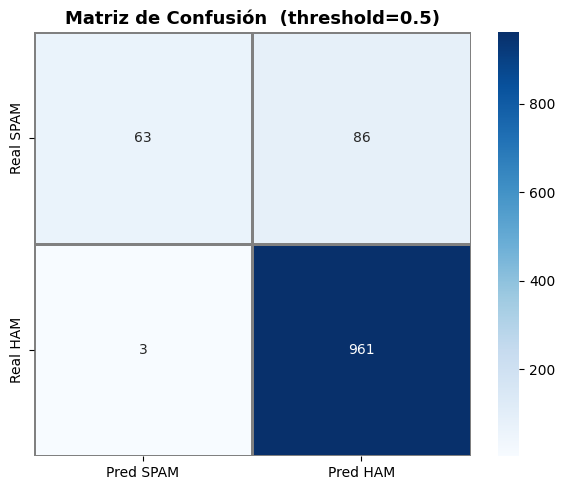

[✓] confusion_matrix.png guardada.


In [13]:
# ── Visualización matriz de confusión ────────────────────────────────────────
cm = np.array([[TP, FN], [FP, TN]])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred SPAM","Pred HAM"],
            yticklabels=["Real SPAM","Real HAM"],
            linewidths=1, linecolor="gray")
ax.set_title(f"Matriz de Confusión  (threshold={THRESHOLD})", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("[✓] confusion_matrix.png guardada.")

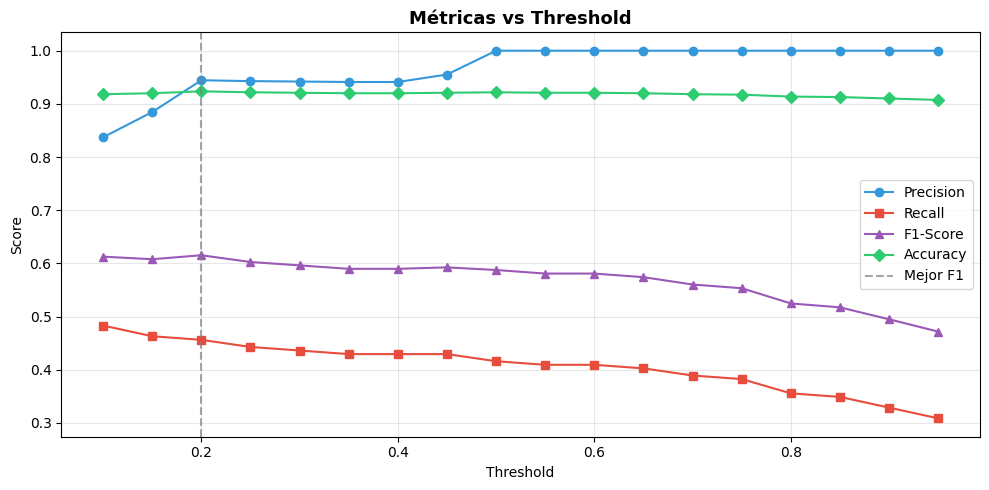


Mejor threshold por F1: 0.2
 threshold  precision   recall       f1  accuracy
      0.10   0.837209 0.483221 0.612766  0.918239
      0.15   0.884615 0.463087 0.607930  0.920036
      0.20   0.944444 0.456376 0.615385  0.923630
      0.25   0.942857 0.442953 0.602740  0.921833
      0.30   0.942029 0.436242 0.596330  0.920934
      0.35   0.941176 0.429530 0.589862  0.920036
      0.40   0.941176 0.429530 0.589862  0.920036
      0.45   0.955224 0.429530 0.592593  0.920934
      0.50   1.000000 0.416107 0.587678  0.921833
      0.55   1.000000 0.409396 0.580952  0.920934
      0.60   1.000000 0.409396 0.580952  0.920934
      0.65   1.000000 0.402685 0.574163  0.920036
      0.70   1.000000 0.389262 0.560386  0.918239
      0.75   1.000000 0.382550 0.553398  0.917341
      0.80   1.000000 0.355705 0.524752  0.913747
      0.85   1.000000 0.348993 0.517413  0.912848
      0.90   1.000000 0.328859 0.494949  0.910153
      0.95   1.000000 0.308725 0.471795  0.907457


In [14]:
# ── Explorar distintos thresholds ────────────────────────────────────────────
thresholds = np.arange(0.1, 1.0, 0.05)
results = []

for thr in thresholds:
    yp = ["spam" if p >= thr else "ham" for p in y_probs]
    tp = sum(1 for t,p in zip(y_true,yp) if t=="spam" and p=="spam")
    fp = sum(1 for t,p in zip(y_true,yp) if t=="ham"  and p=="spam")
    fn = sum(1 for t,p in zip(y_true,yp) if t=="spam" and p=="ham")
    tn = sum(1 for t,p in zip(y_true,yp) if t=="ham"  and p=="ham")
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1s  = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    acc  = (tp+tn)/len(y_true)
    results.append({"threshold":round(thr,2), "precision":prec, "recall":rec,
                    "f1":f1s, "accuracy":acc})

res_df = pd.DataFrame(results)

# Gráfica
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_df["threshold"], res_df["precision"], "o-", color="#3498DB", label="Precision")
ax.plot(res_df["threshold"], res_df["recall"],    "s-", color=COLOR_SPAM,  label="Recall")
ax.plot(res_df["threshold"], res_df["f1"],        "^-", color="#9B59B6",  label="F1-Score")
ax.plot(res_df["threshold"], res_df["accuracy"],  "D-", color=COLOR_HAM,  label="Accuracy")
ax.axvline(x=res_df.loc[res_df["f1"].idxmax(), "threshold"],
           color="gray", linestyle="--", alpha=0.7, label="Mejor F1")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Métricas vs Threshold", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

best = res_df.loc[res_df["f1"].idxmax()]
print(f"\nMejor threshold por F1: {best['threshold']}")
print(res_df.to_string(index=False))

---
## E. Discusión de Resultados

### Significado de las métricas

- **Accuracy:** proporción de mensajes clasificados correctamente. Alta accuracy en datasets desbalanceados puede ser engañosa.
- **Precision:** de todos los mensajes marcados como spam, ¿cuántos realmente lo son? Alta precision = pocos falsos positivos (ham marcado como spam).
- **Recall:** de todos los spams reales, ¿cuántos detectamos? Alto recall = pocos spams se escapan.
- **F1-Score:** media armónica entre precision y recall. Es la métrica más equilibrada para este problema.

### Impacto de las decisiones tomadas

| Decisión | Impacto positivo | Impacto negativo |
|----------|-----------------|-----------------|
| Eliminar stopwords | Reduce ruido, mejora señal de palabras clave | Puede perder contexto en mensajes cortos |
| Lematización | Agrupa variantes de una palabra (`call/called/calling`) | Puede unificar palabras con significados distintos |
| Laplace smoothing (α=1) | Evita probabilidad 0 para palabras nuevas | Puede subestimar palabras muy frecuentes |
| Split 80/20 estratificado | Mantiene proporción spam/ham en train y test | Con datasets pequeños puede no generalizar bien |

### Elección del threshold

Un threshold bajo (< 0.5) aumenta el recall — detectamos más spam pero también más falsos positivos. Un threshold alto (> 0.5) aumenta la precision — menos falsos positivos pero podemos dejar pasar spam. El mejor threshold es aquel que maximiza el F1-Score, balanceando ambas métricas según la necesidad del sistema.


---
## Módulo Interactivo — Presentación en Vivo

Ingresa cualquier texto y el modelo retorna:
- La probabilidad de que sea SPAM
- Las 3 palabras con mayor poder predictivo


In [15]:
def clasificar_mensaje(texto: str, threshold: float = 0.5):
    """
    Módulo de presentación.
    Acepta un texto y retorna probabilidad de spam + top 3 palabras predictivas.
    """
    prob, label, top3 = classify(texto, threshold=threshold)

    print("=" * 60)
    print("CLASIFICADOR SPAM/HAM")
    print("=" * 60)
    print(f"Texto   : {texto[:100]}")
    print(f"P(spam) : {prob:.4f}  ({prob*100:.1f}%)")
    print(f"Clase   : {'🔴 SPAM' if label == 'spam' else '🟢 HAM'}")
    print(f"\nTop 3 palabras con mayor poder predictivo:")
    if top3:
        for i, (word, p) in enumerate(top3, 1):
            bar = "█" * int(p * 20)
            print(f"  {i}. '{word}'  P(S|W)={p:.4f}  {bar}")
    else:
        print("  (no se encontraron palabras en el vocabulario)")
    print("=" * 60)

# ── Prueba con el threshold óptimo encontrado ─────────────────────────────────
best_threshold = res_df.loc[res_df["f1"].idxmax(), "threshold"]
print(f"Usando threshold óptimo: {best_threshold}\n")

mensajes_prueba = [
    "WINNER!! You have been selected to receive a cash prize of £900. Call now!",
    "Hey are you coming to the party tonight? Let me know",
    "FREE entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005",
    "I'm gonna be home soon, don't worry about me",
    "Urgent! Your mobile account has been credited with a bonus. Claim now!"
]

for msg in mensajes_prueba:
    clasificar_mensaje(msg, threshold=best_threshold)
    print()

Usando threshold óptimo: 0.2

CLASIFICADOR SPAM/HAM
Texto   : WINNER!! You have been selected to receive a cash prize of £900. Call now!
P(spam) : 0.9986  (99.9%)
Clase   : 🔴 SPAM

Top 3 palabras con mayor poder predictivo:
  1. 'prize'  P(S|W)=0.9646  ███████████████████
  2. 'winner'  P(S|W)=0.8451  ████████████████
  3. 'selected'  P(S|W)=0.7408  ██████████████

CLASIFICADOR SPAM/HAM
Texto   : Hey are you coming to the party tonight? Let me know
P(spam) : 0.0000  (0.0%)
Clase   : 🟢 HAM

Top 3 palabras con mayor poder predictivo:
  1. 'party'  P(S|W)=0.0566  █
  2. 'know'  P(S|W)=0.0457  
  3. 'tonight'  P(S|W)=0.0271  

CLASIFICADOR SPAM/HAM
Texto   : FREE entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005
P(spam) : 0.8861  (88.6%)
Clase   : 🔴 SPAM

Top 3 palabras con mayor poder predictivo:
  1. 'entry'  P(S|W)=0.8863  █████████████████
  2. 'wkly'  P(S|W)=0.8352  ████████████████
  3. 'comp'  P(S|W)=0.6092  ████████████

CLASIFICADOR SPAM/HAM
Texto   : I'm gonna be home

In [16]:
# ── Celda interactiva — escribe tu propio mensaje ────────────────────────────
mi_mensaje = "Write your message here to test"   # <-- cambia esto

clasificar_mensaje(mi_mensaje, threshold=best_threshold)

CLASIFICADOR SPAM/HAM
Texto   : Write your message here to test
P(spam) : 0.0003  (0.0%)
Clase   : 🟢 HAM

Top 3 palabras con mayor poder predictivo:
  1. 'message'  P(S|W)=0.2284  ████
  2. 'write'  P(S|W)=0.0465  
  3. 'test'  P(S|W)=0.0182  


In [17]:
import pandas as pd

test_df_ext = pd.read_excel("spam-testset.xlsx")
print(test_df_ext.shape)
print(test_df_ext.columns.tolist())
display(test_df_ext.head(5))

(44, 2)
['id', 'text']


,id,text
0,3579,Multiply the numbers independently and count d...
1,4926,Once free call me sir.
2,2951,Hey now am free you can call me.
3,693,Will purchase d stuff today and mail to you. D...
4,1081,Can u get pic msgs to your phone?


In [18]:
import pandas as pd
from openpyxl import load_workbook

# Cargar testset
test_ext = pd.read_excel("spam-testset.xlsx")
test_ext.columns = test_ext.columns.str.strip()

# Definir threshold manualmente si res_df no está definido
try:
    best_threshold = res_df.loc[res_df["f1"].idxmax(), "threshold"]
except NameError:
    best_threshold = 0.5  # valor por defecto
    print(f"⚠️  res_df no encontrado, usando threshold={best_threshold}")

print(f"Threshold usado: {best_threshold}")

# Aplicar modelo
resultados = []
for _, row in test_ext.iterrows():
    prob, label, top3 = classify(str(row["text"]), threshold=best_threshold)
    resultados.append({
        "id":     row["id"],
        "text":   row["text"],
        "p_spam": round(prob, 4),
        "clase":  label.upper(),
        "top3":   ", ".join([f"{w}({p:.3f})" for w, p in top3])
    })

resultados_df = pd.DataFrame(resultados)
display(resultados_df)

resultados_df.to_csv("resultados_testset.csv", index=False)
print(f"\n[✓] Guardado en resultados_testset.csv")
print(f"\nResumen:")
print(resultados_df["clase"].value_counts().to_string())

Threshold usado: 0.2


,id,text,p_spam,clase,top3
0,3579,Multiply the numbers independently and count d...,0.0000,HAM,"point(0.295), number(0.196), multiply(0.163)"
1,4926,Once free call me sir.,0.0114,HAM,"free(0.591), call(0.364), sir(0.014)"
2,2951,Hey now am free you can call me.,0.0111,HAM,"free(0.591), call(0.364), hey(0.013)"
3,693,Will purchase d stuff today and mail to you. D...,0.0001,HAM,"po(0.778), box(0.678), purchase(0.438)"
4,1081,Can u get pic msgs to your phone?,0.0002,HAM,"pic(0.394), phone(0.199), msg(0.181)"
5,2297,Draw va?i dont think so:),0.0065,HAM,"draw(0.768), dont(0.045), think(0.040)"
6,908,WHITE FUDGE OREOS ARE IN STORES,0.0017,HAM,"store(0.406), fudge(0.163), oreo(0.115)"
7,2091,Then get some cash together and I'll text jason,0.0003,HAM,"cash(0.665), text(0.390), jason(0.115)"
8,4057,Noice. Text me when you're here,0.1108,HAM,"text(0.390), noice(0.163)"
9,498,"Kate jackson rec center before 7ish, right?",0.0000,HAM,"rec(0.280), center(0.206), jackson(0.163)"



[✓] Guardado en resultados_testset.csv

Resumen:
clase
HAM    44


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Widgets ──────────────────────────────────────────────────────────────────
texto_input = widgets.Textarea(
    placeholder="Escribe un mensaje aquí...",
    layout=widgets.Layout(width="100%", height="80px")
)
threshold_slider = widgets.FloatSlider(
    value=best_threshold, min=0.1, max=0.9, step=0.05,
    description="Threshold:", readout_format=".2f",
    layout=widgets.Layout(width="50%")
)
boton = widgets.Button(
    description="Clasificar",
    button_style="primary",
    layout=widgets.Layout(width="150px")
)
output = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        texto = texto_input.value.strip()
        if not texto:
            print("⚠️  Escribe un mensaje primero.")
            return
        prob, label, top3 = classify(texto, threshold=threshold_slider.value)
        emoji = " SPAM" if label == "spam" else " HAM"
        print("=" * 55)
        print(f"  Texto   : {texto[:80]}{'...' if len(texto)>80 else ''}")
        print(f"  P(spam) : {prob:.4f}  ({prob*100:.1f}%)")
        print(f"  Clase   : {emoji}")
        print(f"\n  Top 3 palabras más predictivas:")
        for i, (w, p) in enumerate(top3, 1):
            bar = "█" * int(p * 30)
            print(f"    {i}. '{w}'  {p:.4f}  {bar}")
        print("=" * 55)

boton.on_click(on_click)

display(
    widgets.VBox([
        widgets.Label(" Clasificador SPAM/HAM"),
        texto_input,
        threshold_slider,
        boton,
        output
    ])
)